In [1]:
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Bio.Data.IUPACData import protein_letters_3to1_extended
from Bio.PDB.NeighborSearch import NeighborSearch
from Bio.PDB.PDBParser import PDBParser
from Bio.PDB.ResidueDepth import ResidueDepth
from Bio.PDB.SASA import ShrakeRupley
from tqdm import tqdm

tqdm.pandas()

MSMS_EXEC = Path("~/miniconda3/bin/msms")
DATA_FILE_IN = Path("data/all_data_flags_max_with_repeat_all_update.csv")
AF_PDB_LIST = list(Path("data/af2_model1/").iterdir())
FEATURE_FILE_OUT = Path("data/feature_5se_sasa_rd_df.json")

NEIGHBOR_RADIUS_BINS = [i for i in range(3, 16, 3)]
AMINO_ACID_MAP = {key.upper(): i for i, key in enumerate(protein_letters_3to1_extended)}
AF2_SS_FLAGS = {"H": 0, "G": 0, "E": 1, "C": 2, "T": 2, "B": 2, "b": 2}  # if H or G: helix | elif E: beta  | else: coil

MAX_AA_ASA = {
    "ALA": 129.0,
    "ARG": 274.0,
    "ASN": 195.0,
    "ASP": 193.0,
    "CYS": 167.0,
    "GLU": 223.0,
    "GLN": 225.0,
    "GLY": 104.0,
    "HIS": 224.0,
    "ILE": 197.0,
    "LEU": 201.0,
    "LYS": 236.0,
    "MET": 224.0,
    "PHE": 240.0,
    "PRO": 159.0,
    "SER": 155.0,
    "THR": 172.0,
    "TRP": 285.0,
    "TYR": 263.0,
    "VAL": 174.0,
}  # https://doi.org/10.1371/journal.pone.0080635

In [2]:
def make_neighbor_feature(pdb_path: Path):
    parser = PDBParser()
    structure = parser.get_structure(pdb_path.stem, pdb_path)
    residues = [r for r in structure.get_residues() if "CA" in r]
    ca_atoms = [r["CA"] for r in residues]
    model = structure[0]

    sr = ShrakeRupley()
    sr.compute(structure, level="R")

    rd = ResidueDepth(model, str(MSMS_EXEC))

    ns = NeighborSearch(ca_atoms)

    per_residue_neighbors = {}

    for i, residue in enumerate(residues):
        key = (i + 1, residue.resname)

        per_residue_neighbors[key] = {}
        neighbors_accounted_for = set()

        for radius in NEIGHBOR_RADIUS_BINS:
            neighbors_within_radius = set(ns.search(residue["CA"].coord, radius, "R"))
            neighbors_within_radius.remove(residue)
            exclusive_neighbors = neighbors_within_radius - neighbors_accounted_for
            neighbors_accounted_for |= exclusive_neighbors

            aa_indices = [AMINO_ACID_MAP[nbr.resname] for nbr in exclusive_neighbors]
            nbr_sasa = [min(1.0, nbr.sasa / MAX_AA_ASA[nbr.resname]) for nbr in exclusive_neighbors]
            nbr_depths = [rd[(residue.get_parent().id, nbr.get_id())][0] for nbr in exclusive_neighbors]

            ohe_neighbor = np.bincount(aa_indices, minlength=len(AMINO_ACID_MAP))
            sasa_vec = np.divide(
                np.bincount(aa_indices, weights=nbr_sasa, minlength=len(AMINO_ACID_MAP)),
                ohe_neighbor,
                out=np.full_like(ohe_neighbor, np.nan, float),
                where=ohe_neighbor > 0,
            )
            depth_vec = np.divide(
                np.bincount(aa_indices, weights=nbr_depths, minlength=len(AMINO_ACID_MAP)),
                ohe_neighbor,
                out=np.full_like(ohe_neighbor, np.nan, float),
                where=ohe_neighbor > 0,
            )
            total_neighbors = ohe_neighbor.sum()

            per_residue_neighbors[key][radius] = {
                "nbr": ohe_neighbor,
                "nbr_sasa": sasa_vec,
                "nbr_depth": depth_vec,
                "n_nbr": total_neighbors,
            }

    return pdb_path.name, per_residue_neighbors


with ProcessPoolExecutor(max_workers=24) as executor:
    all_neighbors = {
        name: per_residue_neighbors
        for name, per_residue_neighbors in tqdm(
            executor.map(make_neighbor_feature, AF_PDB_LIST),
            desc="Proteins",
            total=len(AF_PDB_LIST),
        )
    }

Proteins:   0%|          | 0/7219 [00:00<?, ?it/s]

Proteins:   0%|          | 22/7219 [00:04<28:17,  4.24it/s]sphere_mange_arete: inconcistence
ERROR: find_SES_contact_faces: inf==0 for face 4816
Proteins:  17%|█▋        | 1231/7219 [00:32<02:20, 42.65it/s]tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
Proteins:  29%|██▉       | 2107/7219 [00:53<01:21, 62.38it/s]sphere_mange_arete: inconcistence
sphere_mange_arete: inconcistence
sphere_mange_arete: inconcistence
Proteins:  48%|████▊     | 3438/7219 [01:28<01:51, 33.79it/s]tri_norm: face with normal vector of lenght 0
tri_norm: face with normal vector of lenght 0
tri_norm: face wit

In [7]:
def make_feature(row):
    af = f"{row['pdb']}_af2_model1.pdb"
    key = (row["res_num"], row["res_name"])

    try:
        neighbor = all_neighbors[af][key]
    except KeyError:
        print(af, key)
        af = None
        neighbor = {rad: {"nbr": None, "nbr_sasa": None, "nbr_depth": None, "n_nbr": None} for rad in NEIGHBOR_RADIUS_BINS}

    res_ohe = np.zeros(len(AMINO_ACID_MAP))
    res_ohe[AMINO_ACID_MAP[row["res_name"]]] = 1

    af2_ss_ohe = np.zeros(len(set(AF2_SS_FLAGS.values())), dtype=int)
    af2_ss_ohe[AF2_SS_FLAGS[row["af2_max_flag"]]] = 1

    nmr_ss_ohe = np.zeros_like(af2_ss_ohe, dtype=int)
    nmr_ss_ohe[AF2_SS_FLAGS[row["nmr_max_flag"]]] = 1

    features = {}
    features["af2_pdb"] = af
    features["res_num"] = row["res_num"]
    features["res_name"] = row["res_name"]

    features["residue"] = res_ohe
    features |= {f"nbr_s{shell + 1}": neighbor[rad]["nbr"] for shell, rad in enumerate(NEIGHBOR_RADIUS_BINS)}
    features |= {f"nbr_sasa_s{shell + 1}": neighbor[rad]["nbr_sasa"] for shell, rad in enumerate(NEIGHBOR_RADIUS_BINS)}
    features |= {f"nbr_depth_s{shell + 1}": neighbor[rad]["nbr_depth"] for shell, rad in enumerate(NEIGHBOR_RADIUS_BINS)}

    features["af2_sd"] = row["af2_sd"]
    features["af2_max_ss%"] = row["af2_max_ss%"] / 100
    features["af2_max_flag"] = af2_ss_ohe
    features["af2_max_flag_clf"] = AF2_SS_FLAGS[row["af2_max_flag"]]
    features["af2_flag_repeat_len"] = row["af2_flag_repeat_len"]
    features["plddt"] = row["plddt"]

    features["nmr_sd"] = row["nmr_sd"]
    features["nmr_max_ss%"] = row["nmr_max_ss%"] / 100
    features["nmr_max_flag"] = nmr_ss_ohe
    features["nmr_max_flag_clf"] = AF2_SS_FLAGS[row["nmr_max_flag"]]
    features["nmr_flag_repeat_len"] = row["nmr_flag_repeat_len"]
    features["lddt"] = row["lddt"]

    features["max_flag_mismatch"] = features["af2_max_flag_clf"] != features["nmr_max_flag_clf"]

    return pd.Series(features)


df = pd.read_csv(DATA_FILE_IN)
feature_df = df.progress_apply(make_feature, axis=1).dropna()
feature_df.to_json(FEATURE_FILE_OUT, orient="records")
feature_df

 26%|██▌       | 124487/482953 [00:10<00:26, 13597.17it/s]

2BC7_af2_model1.pdb (3, 'CYS')
2BC7_af2_model1.pdb (4, 'SER')
2BC7_af2_model1.pdb (5, 'ASP')
2BC7_af2_model1.pdb (6, 'PRO')
2BC7_af2_model1.pdb (7, 'ARG')
2BC7_af2_model1.pdb (9, 'ALA')
2BC7_af2_model1.pdb (10, 'TRP')
2BC7_af2_model1.pdb (11, 'ARG')
2BC7_af2_model1.pdb (12, 'CYS')
2BC8_af2_model1.pdb (4, 'SER')
2BC8_af2_model1.pdb (5, 'ASP')
2BC8_af2_model1.pdb (6, 'PRO')
2BC8_af2_model1.pdb (7, 'ARG')
2BC8_af2_model1.pdb (9, 'ALA')
2BC8_af2_model1.pdb (10, 'TRP')
2BC8_af2_model1.pdb (11, 'ARG')


100%|██████████| 482953/482953 [01:04<00:00, 7434.77it/s] 


,af2_pdb,res_num,res_name,residue,nbr_s1,nbr_s2,nbr_s3,nbr_s4,nbr_s5,nbr_sasa_s1,...,af2_max_flag_clf,af2_flag_repeat_len,plddt,nmr_sd,nmr_max_ss%,nmr_max_flag,nmr_max_flag_clf,nmr_flag_repeat_len,lddt,max_flag_mismatch
0,1B75_af2_model1.pdb,1,MET,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 1, 0, 0, 0, 0, ...","[4, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 2, 0, 1, 0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",...,2,2,0.7469,0.0942,1.00,"[0, 0, 1]",2,2,0.7381,False
1,1B75_af2_model1.pdb,2,PHE,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...","[0, 0, 0, 2, 1, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, ...","[2, 0, 0, 1, 0, 0, 0, 1, 4, 0, 0, 2, 0, 1, 0, ...","[3, 0, 2, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",...,2,2,0.8991,0.0440,0.50,"[0, 0, 1]",2,2,0.8016,False
2,1B75_af2_model1.pdb,3,THR,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, ...","[1, 0, 0, 2, 1, 0, 0, 1, 4, 1, 1, 0, 0, 1, 0, ...","[4, 0, 3, 3, 1, 1, 1, 3, 1, 0, 1, 1, 0, 0, 1, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",...,1,6,0.9368,0.0279,0.80,"[0, 1, 0]",1,6,0.8598,False
3,1B75_af2_model1.pdb,4,ILE,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, ...","[1, 0, 1, 0, 1, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, ...","[2, 0, 2, 3, 2, 1, 1, 2, 3, 0, 3, 1, 0, 1, 0, ...","[2, 0, 1, 2, 1, 0, 1, 3, 2, 2, 0, 0, 1, 0, 1, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",...,1,6,0.9445,0.0257,1.00,"[0, 1, 0]",1,6,0.8634,False
4,1B75_af2_model1.pdb,5,ASN,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 2, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...","[1, 0, 1, 2, 1, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, ...","[2, 0, 0, 0, 3, 0, 0, 3, 2, 1, 3, 2, 1, 1, 1, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",...,1,6,0.9526,0.0448,1.00,"[0, 1, 0]",1,6,0.7764,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482948,9VG5_af2_model1.pdb,112,GLY,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0, 0, 0, 1, 0, ...","[0, 0, 1, 1, 1, 1, 0, 0, 0, 3, 0, 0, 0, 1, 1, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",...,2,4,0.5886,0.0807,0.90,"[0, 0, 1]",2,7,0.7851,False
482949,9VG5_af2_model1.pdb,113,PHE,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",...,2,4,0.5476,0.0964,0.95,"[0, 0, 1]",2,7,0.6531,False
482950,9VG5_af2_model1.pdb,114,GLY,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",...,2,4,0.4675,0.1117,0.95,"[0, 0, 1]",2,7,0.6298,False
482951,9VG5_af2_model1.pdb,115,MET,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",

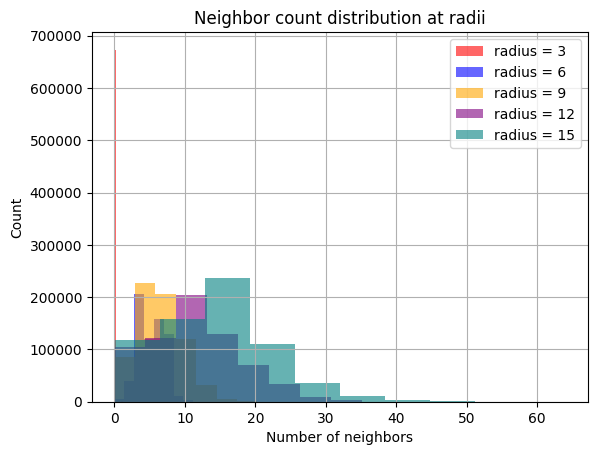

In [6]:
def get_neighbors_hist(all_neighbors, neighbor_radius_bins: list[int]):
    num_neighbors = {rad: list() for rad in neighbor_radius_bins}
    for per_residue_neighbors in all_neighbors.values():
        for neighborhood in per_residue_neighbors.values():
            for radius in neighbor_radius_bins:
                num_neighbors[radius].append(neighborhood[radius]["n_nbr"])

    fig, ax = plt.subplots()
    ax.set_xlabel("Number of neighbors")
    ax.set_ylabel("Count")
    ax.set_title("Neighbor count distribution at radii")
    # ax.set_yscale("log")
    colors = ["red", "blue", "orange", "purple", "teal", "green"]
    for rad, color in zip(num_neighbors, colors):
        _ = pd.Series(num_neighbors[rad]).hist(ax=ax, color=color, alpha=0.6, label=f"radius = {rad}")
    ax.legend()


get_neighbors_hist(all_neighbors, NEIGHBOR_RADIUS_BINS)

In [5]:
# feature_df.to_json(feature_file, orient="records")
# 482937 rows × 15 columns

In [4]:
feature_df.af2_pdb.nunique()

6281

In [8]:
df.columns

Index(['pdb', 'res_name', 'res_num', 'nmr_model', 'lddt', 'nmr_sd', 'plddt',
       'af2_sd', 'nmr_max_ss%', 'nmr_max_flag', 'nmr_flag_repeat_len',
       'af2_max_ss%', 'af2_max_flag', 'af2_flag_repeat_len'],
      dtype='object')

In [ ]:
df = pd.read_csv(DATA_FILE_IN)

In [ ]:
feature_df = pd.read_json(FEATURE_FILE_OUT)

,af2_pdb,res_num,res_name,residue,nbr_s1,nbr_s2,nbr_s3,nbr_s4,nbr_s5,nbr_sasa_s1,...,af2_max_flag_clf,af2_flag_repeat_len,plddt,nmr_sd,nmr_max_ss%,nmr_max_flag,nmr_max_flag_clf,nmr_flag_repeat_len,lddt,max_flag_mismatch
0,1B75_af2_model1.pdb,1,MET,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 1, 0, 0, 0, 0, ...","[4, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 2, 0, 1, 0, ...","[None, None, None, None, None, None, None, Non...",...,2,2,0.7469,0.0942,1.00,"[0, 0, 1]",2,2,0.7381,False
1,1B75_af2_model1.pdb,2,PHE,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...","[0, 0, 0, 2, 1, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, ...","[2, 0, 0, 1, 0, 0, 0, 1, 4, 0, 0, 2, 0, 1, 0, ...","[3, 0, 2, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, ...","[None, None, None, None, None, None, None, Non...",...,2,2,0.8991,0.0440,0.50,"[0, 0, 1]",2,2,0.8016,False
2,1B75_af2_model1.pdb,3,THR,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, ...","[1, 0, 0, 2, 1, 0, 0, 1, 4, 1, 1, 0, 0, 1, 0, ...","[4, 0, 3, 3, 1, 1, 1, 3, 1, 0, 1, 1, 0, 0, 1, ...","[None, None, None, None, None, None, None, Non...",...,1,6,0.9368,0.0279,0.80,"[0, 1, 0]",1,6,0.8598,False
3,1B75_af2_model1.pdb,4,ILE,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, ...","[1, 0, 1, 0, 1, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, ...","[2, 0, 2, 3, 2, 1, 1, 2, 3, 0, 3, 1, 0, 1, 0, ...","[2, 0, 1, 2, 1, 0, 1, 3, 2, 2, 0, 0, 1, 0, 1, ...","[None, None, None, None, None, None, None, Non...",...,1,6,0.9445,0.0257,1.00,"[0, 1, 0]",1,6,0.8634,False
4,1B75_af2_model1.pdb,5,ASN,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 2, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...","[1, 0, 1, 2, 1, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, ...","[2, 0, 0, 0, 3, 0, 0, 3, 2, 1, 3, 2, 1, 1, 1, ...","[None, None, None, None, None, None, None, Non...",...,1,6,0.9526,0.0448,1.00,"[0, 1, 0]",1,6,0.7764,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482932,9VG5_af2_model1.pdb,112,GLY,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0, 0, 0, 1, 0, ...","[0, 0, 1, 1, 1, 1, 0, 0, 0, 3, 0, 0, 0, 1, 1, ...","[None, None, None, None, None, None, None, Non...",...,2,4,0.5886,0.0807,0.90,"[0, 0, 1]",2,7,0.7851,False
482933,9VG5_af2_model1.pdb,113,PHE,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, ...","[None, None, None, None, None, None, None, Non...",...,2,4,0.5476,0.0964,0.95,"[0, 0, 1]",2,7,0.6531,False
482934,9VG5_af2_model1.pdb,114,GLY,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...","[None, None, None, None, None, None, None, Non...",...,2,4,0.4675,0.1117,0.95,"[0, 0, 1]",2,7,0.6298,False
482935,9VG5_af2_model1.pdb,115,MET,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",